This notebook studies the SSh model and edge states.And this is my first try to use Jupyter.Maybe I will make abundance mistakes.

Firstly,we construst a 1D SSH model with two sites per unit cell.
t1:intracell hopping
t2:intercell hopping

In [22]:

# %matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

#参数
N = 40      #单元数
t1 = 1.0
t2 = 1.5

#构造哈密顿量(open boundary)
H = np.zeros((2*N,2*N))

for i in range(N):
    # intracell hopping
    H[2*i,2*i+1] = t1
    H[2*i+1,2*i] = t1

    # intercell hopping
    if i < N-1:
        H[2*i+1,2*(i+1)] = t2
        H[2*(i+1),2*i+1] = t2

Secondly,we diagonalize the Hamiltonian to obtain eigenvalues and eigenvector

In [23]:
# 对角化
E,V = np.linalg.eigh(H)


Thirdly,we plot the energy spectrum under open boundary condition.Edge states appear near zero energy when t1 < t2.


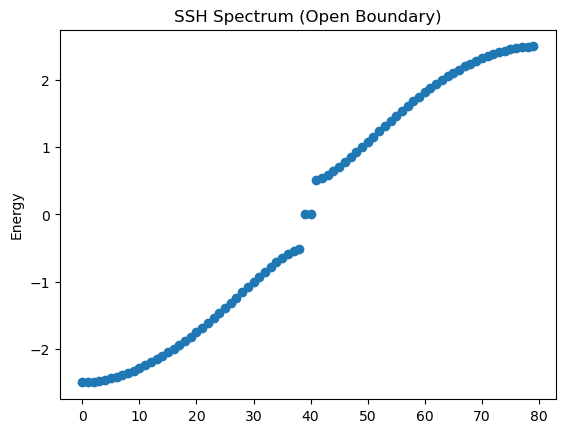

In [24]:
# 画能谱
plt.plot(E,"o")
plt.ylabel("Energy")
plt.title("SSH Spectrum (Open Boundary)")
plt.show()

We plot the probability distribution |ψ|^2.The wavefunction is localized at both ends,indicating edge states.


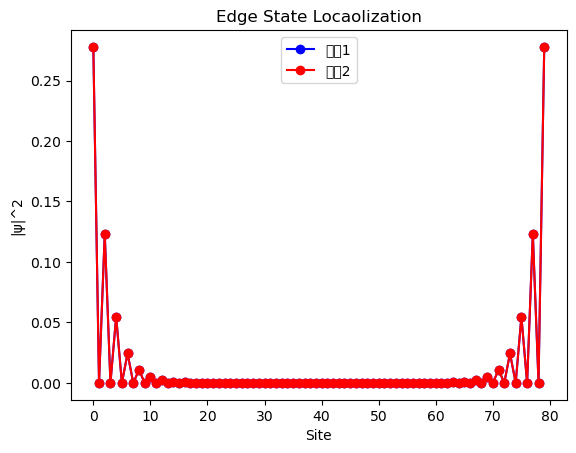

In [25]:
# 找最接近0的态
idx = np.argsort(np.abs(E)) #argsort:排序但只保存原来下标

psi1 = V[:,idx[0]]
psi2 = V[:,idx[1]]
#画概率分布
plt.plot(np.abs(psi1)**2,"-o",label = '状态1',color = 'b')
plt.plot(np.abs(psi2)**2,"-o",label = '状态2',color = 'r')
plt.legend()
plt.xlabel("Site")
plt.ylabel("|ψ|^2")
plt.title("Edge State Locaolization")
plt.show()


This part is used for writing my understanding.What I want to refer to is that though we construct two edge states with different colors,there is just a res curve.I think it may because we are plotting |ψ|^2.The eigenstates botained from diagonalization are actually symmetric and antisymmetric combinations of the left and right edge states.Since probability density |ψ|^2 is insensitive to sign,both states appear almost identical in the plot.And we can solve the problem using a linear combination.

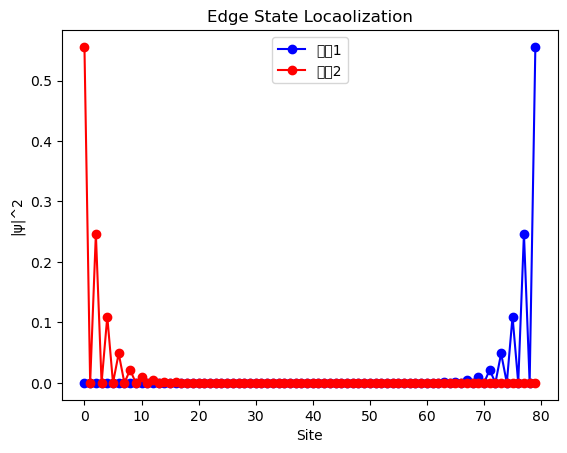

In [26]:
psi_L = (psi1 + psi2)/np.sqrt(2)
psi_R = (psi1 - psi2)/np.sqrt(2)

plt.plot(np.abs(psi_L)**2,"-o",label = '状态1',color = 'b')
plt.plot(np.abs(psi_R)**2,"-o",label = '状态2',color = 'r')
plt.legend()
plt.xlabel("Site")
plt.ylabel("|ψ|^2")
plt.title("Edge State Locaolization")
plt.show()

I fell so content for seeing the chart

And we can also try to change the conditions(t1 > t2) 

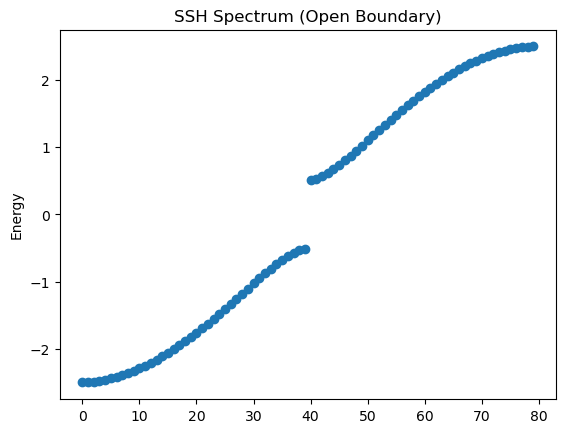

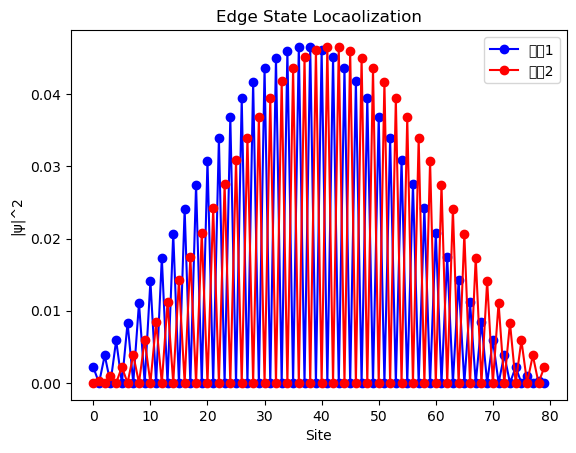

In [27]:
# %matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

#参数
N = 40      #单元数
t1 = 1.5
t2 = 1.0

#构造哈密顿量(open boundary)
H = np.zeros((2*N,2*N))

for i in range(N):
    # intracell hopping
    H[2*i,2*i+1] = t1
    H[2*i+1,2*i] = t1

    # intercell hopping
    if i < N-1:
        H[2*i+1,2*(i+1)] = t2
        H[2*(i+1),2*i+1] = t2

# 对角化
E,V = np.linalg.eigh(H)


# 画能谱
plt.plot(E,"o")
plt.ylabel("Energy")
plt.title("SSH Spectrum (Open Boundary)")
plt.show()


# 找最接近0的态
idx = np.argsort(np.abs(E)) #argsort:排序但只保存原来下标

psi1 = V[:,idx[0]]
psi2 = V[:,idx[1]]
#画概率分布
psi_L = (psi1 + psi2)/np.sqrt(2)
psi_R = (psi1 - psi2)/np.sqrt(2)

plt.plot(np.abs(psi_L)**2,"-o",label = '状态1',color = 'b')
plt.plot(np.abs(psi_R)**2,"-o",label = '状态2',color = 'r')
plt.legend()
plt.xlabel("Site")
plt.ylabel("|ψ|^2")
plt.title("Edge State Locaolization")
plt.show()

Now,it is time to give a summary.
Case 1:t1 > t2 (Trivial Phase)
When the intracell hopping t1 is stronger than the intercell hopping t2,the system is in a trivial phase.
In this case,each unit cell forms a strongly bonded pair(A-B).The chain can be viewed as a collection of isolated dimers(孤立二聚体)
So there are no unpaired sites at the boundaries,no edge states appear in the energy gap and all egienstates are extended bulk states

Case 2:t1 < t2 (Topological Phase)

When the intercell hopping t2 is stronger than the intracell hopping t1,the systerm enters a topological phase.
In this case,the strong bonds connect different unit cells rather than sites within the same unit cell.
So the chain cannot be fully dimerized within the chosen unit cell,unpaired edge sites appear at the boundaries and localized edge states emerge inside the energy gap
